In [2]:
import pickle

def load_dict_pickle(file_path):
    with open(file_path, 'rb') as f:
        return pickle.load(f)

In [3]:
file_folder = '/home/liuycomputing/wsp_sequencing/codes/process_20251218/single_select/'
cellpool_file = 'single_select_cellpool_count_reads_for_perfect_recovery.pkl'
IDs_file_list = [
    'single_select_ID1_count_reads_for_perfect_recovery.pkl',
    'single_select_ID5000_count_reads_for_perfect_recovery.pkl',
    'single_select_ID10000_count_reads_for_perfect_recovery.pkl',
    'single_select_ID20000_count_reads_for_perfect_recovery.pkl',
    'single_select_ID30000_count_reads_for_perfect_recovery.pkl'
]

single_ids_list = [1, 5000, 10000, 20000, 30000]

In [4]:
cellpool_result = load_dict_pickle(file_path=file_folder+cellpool_file)
print(cellpool_result['whole_finded_ids'])

{0: [95062, 9347, 55715, 23013, 79524, 34849, 202991, 40881, 28734, 34494], 4999: [4381, 10554, 2576, 45, 9811, 111, 1384, 5317, 1634, 336], 9999: [109840, 35685, 153417, 22489, 30757, 14887, 61859, 23036, 324039, 16190], 19999: [28576, 10369, 85899, 32875, 546, 560, 5526, 39275, 26281, 18098], 29999: [35788, 122519, 577689, 18115, 127527, 578614, 193880, 122922, 290095, 120070]}


In [5]:
after = {
    'repeat experiments': 10,
    'mean_finded_ids': {},
    'whole_finded_ids': {}
}

for idx, id_file in enumerate(IDs_file_list):
    id_result = load_dict_pickle(file_path=file_folder+id_file)
    after['mean_finded_ids'][single_ids_list[idx] - 1] = id_result['mean_finded_ids'][single_ids_list[idx] - 1]
    after['whole_finded_ids'][single_ids_list[idx] - 1] = id_result['whole_finded_ids'][single_ids_list[idx] - 1]

print(after)

{'repeat experiments': 10, 'mean_finded_ids': {0: 249.3, 4999: 41.5, 9999: 159.8, 19999: 182.7, 29999: 439.7}, 'whole_finded_ids': {0: [77, 25, 37, 51, 30, 7, 30, 1776, 75, 385], 4999: [53, 76, 79, 9, 10, 71, 10, 65, 10, 32], 9999: [11, 405, 203, 172, 89, 23, 71, 300, 267, 57], 19999: [157, 794, 279, 17, 19, 122, 81, 222, 30, 106], 29999: [212, 257, 484, 888, 204, 143, 158, 1124, 813, 114]}}


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

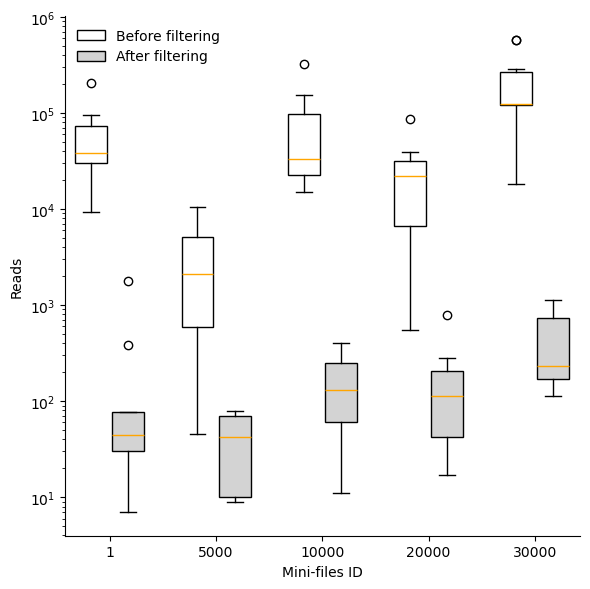

In [13]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['font.family']  = 'Arial'

import matplotlib.pyplot as plt
import numpy as np

IDs = single_ids_list

before_data = [cellpool_result['whole_finded_ids'][i-1] for i in IDs]
after_data  = [after['whole_finded_ids'][i-1] for i in IDs]

x = np.arange(len(IDs))

pos_before = x * 2.0
pos_after  = pos_before + 0.7

plt.figure(figsize=(6,6))

# 筛选前
plt.boxplot(
    before_data,
    positions=pos_before,
    widths=0.6,
    showfliers=True,
    patch_artist=True,
    boxprops=dict(facecolor="white"),
    medianprops=dict(color="orange")
)

# 筛选后
plt.boxplot(
    after_data,
    positions=pos_after,
    widths=0.6,
    showfliers=True,
    patch_artist=True,
    boxprops=dict(facecolor="lightgray"),
    medianprops=dict(color="orange")
)

# x 轴刻度放在中间
plt.xticks(pos_before + 0.35, IDs)

plt.xlabel("Mini-files ID")
plt.ylabel("Reads")
plt.yscale("log")   # ⚠️ 强烈推荐（你的数据跨度太大）
plt.tight_layout()

from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='white', edgecolor='black', label='Before filtering'),
    Patch(facecolor='lightgray', edgecolor='black', label='After filtering')
]

plt.legend(
    handles=legend_elements,
    frameon=False
)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

file_name = '/home/liuycomputing/wsp_sequencing/codes/process_20251218/plot_figures/figure5_d_single_select_boxplot'

plt.savefig(file_name + '.pdf', bbox_inches='tight')
plt.show()